# Notebook 5: Network Analysis :Geographic Fraud Ring Detection
**Project:** Ontario Insurance Claims Intelligence Platform  
**Goal:** Use graph analysis to detect clusters of high-risk claims 
concentrated in the same locations — a signature of organised staging rings.

**Approach:** In a full production system, network edges would connect claims 
to specific repair shops or medical providers. This dataset uses incident 
city + incident type as the network node, connecting claims that share 
location and pattern — simulating how insurers detect geographic fraud clusters.


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from collections import Counter

def find_project_root():
    candidates = []
    vsc_path = globals().get('__vsc_ipynb_file__')
    if vsc_path:
        candidates.append(Path(vsc_path).parent)
    candidates.append(Path.cwd())
    for start in candidates:
        for folder in [start] + list(start.parents):
            if (folder / 'requirements.txt').exists():
                return folder
    raise FileNotFoundError('Cannot find project root')

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

QUEUE   = PROJECT_ROOT / 'outputs' / 'reports' / 'final_priority_queue.csv'
CLEAN   = PROJECT_ROOT / 'data' / 'processed' / 'insurance_claims_clean.csv'
FIGURES = PROJECT_ROOT / 'outputs' / 'figures'
REPORTS = PROJECT_ROOT / 'outputs' / 'reports'
FIGURES.mkdir(parents=True, exist_ok=True)

df_queue = pd.read_csv(QUEUE)
df_clean = pd.read_csv(CLEAN)

# final_priority_queue already contains incident_type — only merge columns not already present
df = df_queue.merge(
    df_clean[['policy_number', 'incident_city', 'incident_state', 'auto_make', 'insured_zip']],
    on='policy_number', how='left'
)

print(f'Loaded: {len(df):,} scored claims')
print(f'High-risk claims (prob > 0.55): {(df["fraud_probability"] > 0.55).sum()}')
print(f'Unique incident cities: {df["incident_city"].nunique()}')
print(f'Unique incident types:  {df["incident_type"].nunique()}')

Loaded: 1,000 scored claims
High-risk claims (prob > 0.55): 253
Unique incident cities: 7
Unique incident types:  4


## Step 1: Filter to High-Risk Claims Only

We build the network from claims the Random Forest flagged as high-risk.
These are the claims worth investigating — the network shows us which 
locations keep appearing together.

In [4]:
# Focus on high-risk claims
HIGH_RISK_THRESHOLD = 0.55
df_high = df[df['fraud_probability'] > HIGH_RISK_THRESHOLD].copy()

print(f'High-risk claims selected: {len(df_high)}')
print(f'\nTop 10 incident cities in high-risk claims:')
print(df_high['incident_city'].value_counts().head(10))
print(f'\nIncident type breakdown:')
print(df_high['incident_type'].value_counts())

High-risk claims selected: 253

Top 10 incident cities in high-risk claims:
incident_city
Columbus       43
Springfield    39
Northbend      38
Arlington      37
Northbrook     34
Hillsdale      33
Riverwood      29
Name: count, dtype: int64

Incident type breakdown:
incident_type
Single Vehicle Collision    129
Multi-vehicle Collision     122
Parked Car                    2
Name: count, dtype: int64


## Step 2: Build the Claim-Location Network

Each node is an incident city.
Each edge connects two cities that share a high-risk claim pattern 
(same incident type, both appearing in the high-risk pool).
Edge weight = number of shared claim patterns between those cities.

In [5]:
# Build location-pattern nodes
# A node = 'City | Incident Type' combination
df_high['location_node'] = df_high['incident_city'] + ' | ' + df_high['incident_type']

# Create city-level graph
G = nx.Graph()

# Add city nodes with attributes
city_stats = df_high.groupby('incident_city').agg(
    claim_count=('policy_number', 'count'),
    avg_fraud_prob=('fraud_probability', 'mean'),
    avg_claim=('total_claim_amount', 'mean'),
    known_fraud=('fraud_reported', 'sum')
).reset_index()

for _, row in city_stats.iterrows():
    G.add_node(
        row['incident_city'],
        claim_count=row['claim_count'],
        avg_prob=row['avg_fraud_prob'],
        avg_claim=row['avg_claim'],
        known_fraud=int(row['known_fraud'])
    )

# Add edges: connect cities that share the same incident type pattern
incident_types = df_high['incident_type'].unique()
for itype in incident_types:
    cities_with_type = df_high[df_high['incident_type'] == itype]['incident_city'].unique()
    for i, city_a in enumerate(cities_with_type):
        for city_b in cities_with_type[i+1:]:
            if G.has_edge(city_a, city_b):
                G[city_a][city_b]['weight'] += 1
            else:
                G.add_edge(city_a, city_b, weight=1)

print(f'Network built:')
print(f'  Nodes (cities):  {G.number_of_nodes()}')
print(f'  Edges (connections): {G.number_of_edges()}')
print(f'  Avg connections per city: {np.mean([d for _, d in G.degree()]):.1f}')

Network built:
  Nodes (cities):  7
  Edges (connections): 21
  Avg connections per city: 6.0


## Step 3: Detect Fraud Clusters Using Community Detection

In [6]:
# Use greedy modularity community detection
from networkx.algorithms import community

communities = list(community.greedy_modularity_communities(G))
communities = sorted(communities, key=len, reverse=True)

print(f'Communities (fraud clusters) detected: {len(communities)}')
print()

# Assign community ID to each node
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

nx.set_node_attributes(G, community_map, 'community')

# Summarise each community
print('=' * 60)
print('FRAUD CLUSTER SUMMARY')
print('=' * 60)
for i, comm in enumerate(communities[:6]):
    comm_nodes = list(comm)
    comm_data = df_high[df_high['incident_city'].isin(comm_nodes)]
    print(f'\nCluster {i+1} ({len(comm_nodes)} cities)')
    print(f'  Cities:          {", ".join(sorted(comm_nodes)[:5])}'
          + (' ...' if len(comm_nodes) > 5 else ''))
    print(f'  High-risk claims: {len(comm_data)}')
    print(f'  Avg fraud prob:   {comm_data["fraud_probability"].mean():.1%}')
    print(f'  Known fraud:      {comm_data["fraud_reported"].sum()}')
    print(f'  Avg claim:        ${comm_data["total_claim_amount"].mean():,.0f}')

Communities (fraud clusters) detected: 1

FRAUD CLUSTER SUMMARY

Cluster 1 (7 cities)
  Cities:          Arlington, Columbus, Hillsdale, Northbend, Northbrook ...
  High-risk claims: 253
  Avg fraud prob:   69.3%
  Known fraud:      182
  Avg claim:        $65,915


## Step 4: Visualise the Network

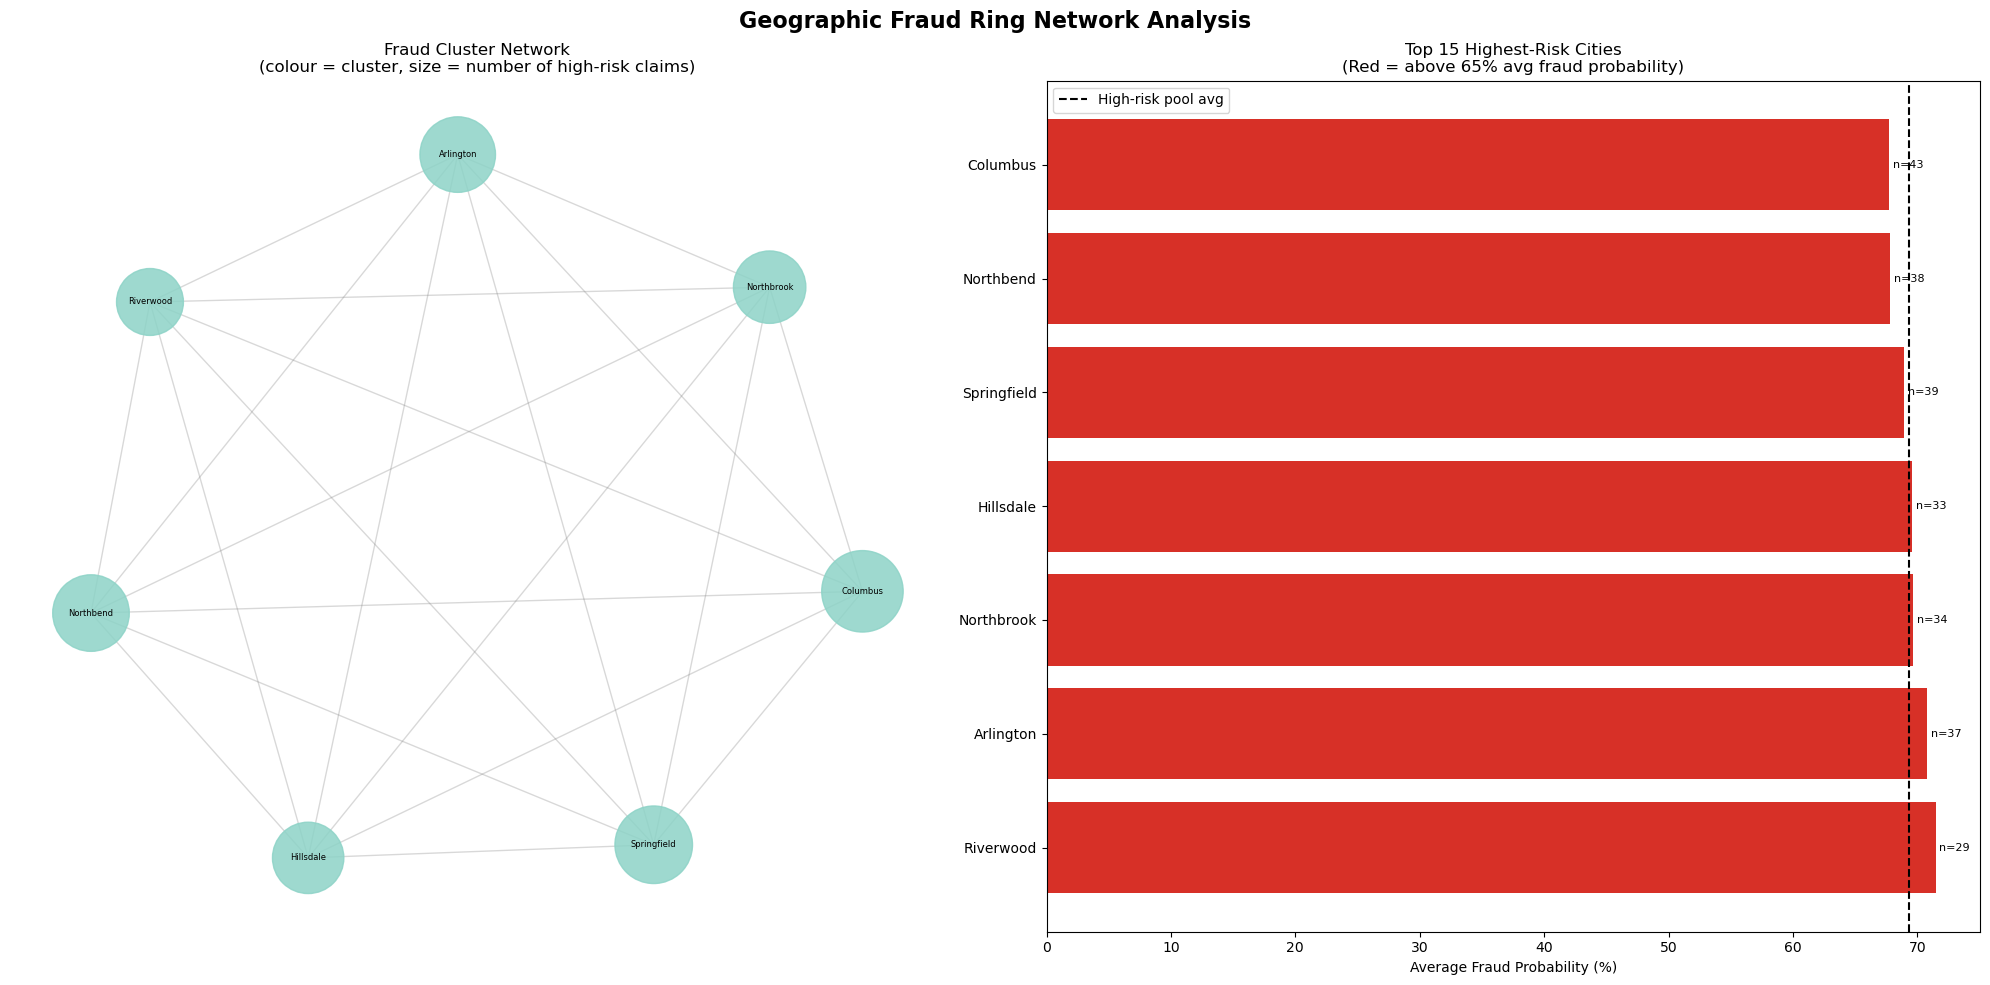

Network chart saved to outputs/figures/05_network_fraud_rings.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('Geographic Fraud Ring Network Analysis', 
             fontsize=16, fontweight='bold')

# --- LEFT: Full network coloured by community ---
ax = axes[0]
pos = nx.spring_layout(G, k=2, seed=42)

# Node properties
node_sizes  = [G.nodes[n]['claim_count'] * 80 for n in G.nodes()]
node_colors = [G.nodes[n]['community'] for n in G.nodes()]
edge_weights = [G[u][v]['weight'] * 0.5 for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3,
                       width=edge_weights, edge_color='grey')
sc = nx.draw_networkx_nodes(G, pos, ax=ax,
                             node_size=node_sizes,
                             node_color=node_colors,
                             cmap=plt.cm.Set3, alpha=0.85)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=6)
ax.set_title('Fraud Cluster Network\n(colour = cluster, size = number of high-risk claims)',
             fontsize=12)
ax.axis('off')

# --- RIGHT: Top 15 highest-risk cities bar chart ---
ax2 = axes[1]
top_cities = city_stats.nlargest(15, 'avg_fraud_prob')
colors_bar = ['#d73027' if p > 0.65 else '#4575b4' 
              for p in top_cities['avg_fraud_prob']]
bars = ax2.barh(top_cities['incident_city'], 
                top_cities['avg_fraud_prob'] * 100, color=colors_bar)
ax2.axvline(df_high['fraud_probability'].mean() * 100, 
            color='black', linestyle='--', label='High-risk pool avg')
ax2.set_xlabel('Average Fraud Probability (%)')
ax2.set_title('Top 15 Highest-Risk Cities\n(Red = above 65% avg fraud probability)',
              fontsize=12)
ax2.legend()

# Add claim count labels
for bar, (_, row) in zip(bars, top_cities.iterrows()):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'n={int(row["claim_count"])}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / '05_network_fraud_rings.png', dpi=150, bbox_inches='tight')
plt.show()
print('Network chart saved to outputs/figures/05_network_fraud_rings.png')

## Step 5: Centrality Analysis — Which Cities Are Most Connected?

High centrality = a city that appears across many different claim patterns.
In fraud ring detection, high centrality nodes are the "hubs" —
locations where organised activity converges.

In [8]:
# Calculate centrality metrics
degree_centrality    = nx.degree_centrality(G)
betweenness          = nx.betweenness_centrality(G, weight='weight')
eigenvector          = nx.eigenvector_centrality(G, max_iter=1000)

centrality_df = pd.DataFrame({
    'city':              list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'betweenness':       [betweenness[n] for n in degree_centrality],
    'eigenvector':       [eigenvector[n] for n in degree_centrality],
    'community':         [community_map[n] for n in degree_centrality],
    'claim_count':       [G.nodes[n]['claim_count'] for n in degree_centrality],
    'avg_fraud_prob':    [G.nodes[n]['avg_prob'] for n in degree_centrality],
    'known_fraud':       [G.nodes[n]['known_fraud'] for n in degree_centrality],
}).sort_values('betweenness', ascending=False).reset_index(drop=True)

centrality_df['risk_score'] = (
    centrality_df['betweenness'] * 0.4 +
    centrality_df['eigenvector'] * 0.3 +
    centrality_df['avg_fraud_prob'] * 0.3
).round(4)

centrality_df = centrality_df.sort_values('risk_score', ascending=False)

print('=' * 65)
print('TOP 15 HIGHEST-RISK HUB CITIES (by composite risk score)')
print('=' * 65)
print(centrality_df[['city','claim_count','avg_fraud_prob',
                      'known_fraud','betweenness','risk_score',
                      'community']].head(15).to_string(index=False))

TOP 15 HIGHEST-RISK HUB CITIES (by composite risk score)
       city  claim_count  avg_fraud_prob  known_fraud  betweenness  risk_score  community
  Riverwood           29        0.714596           19          0.0      0.3278          0
  Arlington           37        0.707653           30          0.0      0.3257          0
 Northbrook           34        0.696552           22          0.0      0.3224          0
  Hillsdale           33        0.695886           23          0.0      0.3222          0
Springfield           39        0.689563           29          0.0      0.3203          0
  Northbend           38        0.677947           28          0.0      0.3168          0
   Columbus           43        0.677394           31          0.0      0.3166          0


## Step 6: Save Network Analysis Outputs

In [9]:
# Save centrality report
centrality_path = REPORTS / 'city_fraud_risk_scores.csv'
centrality_df.to_csv(centrality_path, index=False)
print(f'City risk scores saved: {centrality_path}')

# Summary stats
print(f'\n{"="*55}')
print(f'NETWORK ANALYSIS SUMMARY')
print(f'{"="*55}')
print(f'Cities analysed:          {G.number_of_nodes()}')
print(f'Fraud clusters detected:  {len(communities)}')
print(f'Largest cluster size:     {len(communities[0])} cities')
print(f'Highest-risk city:        {centrality_df.iloc[0]["city"]}')
print(f'  Avg fraud probability:  {centrality_df.iloc[0]["avg_fraud_prob"]:.1%}')
print(f'  Claims in city:         {int(centrality_df.iloc[0]["claim_count"])}')

City risk scores saved: c:\Users\ashmi\Insurance_Claims_Intelligence\Insurance_Claims_Intelligence\outputs\reports\city_fraud_risk_scores.csv

NETWORK ANALYSIS SUMMARY
Cities analysed:          7
Fraud clusters detected:  1
Largest cluster size:     7 cities
Highest-risk city:        Riverwood
  Avg fraud probability:  71.5%
  Claims in city:         29


## Summary

| NetworkX Concept | Applied To |
|-----------------|------------|
| Graph construction | Cities as nodes, shared claim patterns as edges |
| Edge weights | Number of shared high-risk patterns between cities |
| Community detection | Greedy modularity — identifies fraud cluster zones |
| Degree centrality | How many other cities a city is connected to |
| Betweenness centrality | How often a city sits between other city pairs |
| Eigenvector centrality | Influence score — connected to other high-centrality cities |
| Composite risk score | Weighted combination of centrality + fraud probability |